## Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import sawtooth
import scipy
from astropy.table import Table
from scipy.stats import chi2

In [2]:
import iminuit

from iminuit import minimize  # has same interface as scipy.optimize.minimize
from iminuit import Minuit, describe

# we also need a cost function to fit and import the LeastSquares function
from iminuit.cost import LeastSquares
from iminuit.cost import UnbinnedNLL

# Annotated and Gt are imported from iminuit.typing here for universal compatibility,
# but users should in general import them from external packages `typing-extensions` and
# `annotated-types` to decouple models from the `iminuit` package
from iminuit.typing import Annotated, Gt

%config InlineBackend.figure_formats = ['svg']

from iminuit import Minuit

print("iminuit version:", iminuit.__version__)

iminuit version: 2.30.0


## Functions

In [3]:
def read(filename):
    data = pd.read_csv(filename, sep="\\s+", header=None, skiprows=2)
    data.columns = ['time','flux','flux_err']
    return data

In [4]:
def sin(x, A, omega, phi0):
    y = A*np.sin(omega*x + phi0)
    return y

def saw(x, A, omega, phi0):
    y = A*sawtooth(omega*x + phi0, 1.0)
    return y

In [5]:
def fit(filename, initial_guess, function, n):
    data=read(filename)
    A, omega, phi0 = initial_guess
    
    least_squares = LeastSquares(data['time'],data['flux'],data['flux_err'], function)
    m = Minuit(least_squares, A=A, omega=omega, phi0=phi0)  

    time=data['time']
    distance=np.zeros(len(time)-1)
    for i in range(len(time)-1):
        distance[i]=np.abs(time[i]-time[i+1])
    
    omega_max=2*np.pi/np.min(distance)

    m.limits['A'] = (min(abs(data['flux'])),2*(max(data['flux'])-min(data['flux'])))
    m.limits['omega'] = (2*np.pi/(max(data['time'])-min(data['time'])), omega_max) #nel caso si può omettere il due e tornare ad mezzo periodo
    m.limits['phi0'] = (0,2*np.pi)
    
    m.migrad()
    chi2=m.fval/(len(data['time'])-n)

    return m, chi2

In [30]:
def name(num):
    if num<1000:
        file='../../lc_0'+str(num)+'.txt'
    if num<100:
        file='../../lc_00'+str(num)+'.txt'
    if num<10:
        file='../../lc_000'+str(num)+'.txt'
    return file

# Fitting Models and Saving Parameters

In [6]:
n_param=3

In [7]:
initial_guess=[0,0,0] #io metterei 1 di initial guess per A

In [8]:
m_vector_sin=np.array([])
m_vector_saw=np.array([])
chi2_vector_sin=np.array([])
chi2_vector_saw=np.array([])

In [18]:
with open("sin.txt", "w") as f:
    f.write("chi2 ")
    f.write("A ")
    f.write("omega ")
    f.write("phi0 \n")

for i in range(1000):
    
    if i<1000:
        file='drw_lightcurves/lc_0'+str(i)+'.txt'
    if i<100:
        file='drw_lightcurves/lc_00'+str(i)+'.txt'
    if i<10:
        file='drw_lightcurves/lc_000'+str(i)+'.txt'

    data=read(file)
    omega_min=np.pi/(max(data['time'])-min(data['time']))

    time=data['time']
    distance=np.zeros(len(time)-1)
    for i in range(len(time)-1):
        distance[i]=np.abs(time[i]-time[i+1])
    
    omega_max=2*np.pi/np.min(distance)
    omega_vector=np.arange(omega_min,omega_max,0.01)
    print(len(omega_vector))


    chi2_vector_sin_omega=np.array([])
    m_vector_sin_omega=np.array([])
    
    for omega in omega_vector:
        initial_guess[1]=omega
    
        m_sin, chi2_sin=fit(file,initial_guess, sin, n_param)
        m_vector_sin_omega=np.append(m_vector_sin_omega,m_sin)
        chi2_vector_sin_omega=np.append(chi2_vector_sin_omega,chi2_sin)

    chi2_sin=np.min(chi2_vector_sin_omega)
    argmin_sin=np.argmin(chi2_vector_sin_omega)
    m_sin=m_vector_sin_omega[argmin_sin]
    
    params_sin=iminuit.util.ValueView(m_sin)

    with open("sin.txt", "a") as f:
        f.write(str(chi2_sin)+ " ")
        f.write(str(params_sin[0])+ " ")
        f.write(str(params_sin[1])+ " ")
        f.write(str(params_sin[2])+ "\n")
    
    m_vector_sin=np.append(m_vector_sin,m_sin)
    chi2_vector_sin=np.append(chi2_vector_sin,chi2_sin)
    
    print(file, "sin done")

308
drw_lightcurves/lc_0000.txt sin done
314
drw_lightcurves/lc_0001.txt sin done
312
drw_lightcurves/lc_0002.txt sin done
314
drw_lightcurves/lc_0003.txt sin done
314
drw_lightcurves/lc_0004.txt sin done
314
drw_lightcurves/lc_0005.txt sin done
313
drw_lightcurves/lc_0006.txt sin done
314
drw_lightcurves/lc_0007.txt sin done
314
drw_lightcurves/lc_0008.txt sin done
314
drw_lightcurves/lc_0009.txt sin done
314
drw_lightcurves/lc_0010.txt sin done
311
drw_lightcurves/lc_0011.txt sin done
313
drw_lightcurves/lc_0012.txt sin done
314
drw_lightcurves/lc_0013.txt sin done
312
drw_lightcurves/lc_0014.txt sin done
312
drw_lightcurves/lc_0015.txt sin done
314
drw_lightcurves/lc_0016.txt sin done
314
drw_lightcurves/lc_0017.txt sin done
312
drw_lightcurves/lc_0018.txt sin done
314
drw_lightcurves/lc_0019.txt sin done
313
drw_lightcurves/lc_0020.txt sin done
313
drw_lightcurves/lc_0021.txt sin done
314
drw_lightcurves/lc_0022.txt sin done
314
drw_lightcurves/lc_0023.txt sin done
314
drw_lightcur

In [19]:
with open("saw.txt", "w") as f:
    f.write("chi2 ")
    f.write("A ")
    f.write("omega ")
    f.write("phi0 \n")

for i in range(1000):
    
    if i<1000:
        file='drw_lightcurves/lc_0'+str(i)+'.txt'
    if i<100:
        file='drw_lightcurves/lc_00'+str(i)+'.txt'
    if i<10:
        file='drw_lightcurves/lc_000'+str(i)+'.txt'

    data=read(file)
    omega_min=np.pi/(max(data['time'])-min(data['time']))

    time=data['time']
    distance=np.zeros(len(time)-1)
    for j in range(len(time)-1):
        distance[j]=np.abs(time[j]-time[j+1])
    
    omega_max=2*np.pi/np.min(distance)
    omega_vector=np.arange(omega_min,omega_max,0.01)
    print(len(omega_vector))

    chi2_vector_saw_omega=np.array([])
    m_vector_saw_omega=np.array([])

    for omega in omega_vector:
        initial_guess[1]=omega
        
        m_saw, chi2_saw=fit(file,initial_guess, saw, n_param)
        m_vector_saw_omega=np.append(m_vector_saw_omega,m_saw)
        chi2_vector_saw_omega=np.append(chi2_vector_saw_omega,chi2_saw)
    print(chi2_vector_saw_omega)

    chi2_saw=np.min(chi2_vector_saw_omega)
    argmin_saw=np.argmin(chi2_vector_saw_omega)
    m_saw=m_vector_saw_omega[argmin_saw]

    params_saw=iminuit.util.ValueView(m_saw)

    with open("saw.txt", "a") as f:
        f.write(str(chi2_saw)+ " ")
        f.write(str(params_saw[0])+ " ")
        f.write(str(params_saw[1])+ " ")
        f.write(str(params_saw[2])+ "\n")
    
    m_vector_saw=np.append(m_vector_saw,m_saw)
    chi2_vector_saw=np.append(chi2_vector_saw,chi2_saw)

    print(file, "saw done")

308
[29.10321606 26.73559503 25.70222315 28.72332923 26.97538913 29.12620177
 28.04294811 22.79036198 26.09244355 29.95424922 30.27785976 29.76369804
 22.85870669 30.01095962 29.96594591 29.84596143 22.79548417 30.04809722
 22.96450197 30.36905401 30.33219838 23.24265103 24.92252829 27.91051854
 23.33744055 29.90930748 23.92777065 29.57399647 29.68900803 29.4795629
 27.49903957 29.83828433 30.02702992 30.00642397 28.59919536 29.88564962
 29.93654959 30.27677161 23.08630303 27.73135948 23.66056114 30.28939617
 23.28099677 29.49990198 30.04790134 24.74951193 25.69116927 22.59680774
 27.74227978 29.69244285 28.97622743 28.1189928  30.13154617 28.54031048
 29.86843321 30.20252484 30.29581759 29.68131203 29.50692339 29.52062475
 29.26512876 29.93399548 29.08307331 28.96474764 29.0973151  27.0079992
 25.08312564 30.02550339 30.11958717 28.84626107 29.79807437 29.95386916
 30.27658138 29.85247977 29.44959858 29.68910982 29.98539329 22.82209802
 30.19128941 30.10364236 29.55140705 29.28381448 

# Reading Parameters

In [10]:
chi2_vector_sin=np.array([])
chi2_vector_saw=np.array([])

A_sin=np.array([])
omega_sin=np.array([])
phi_sin=np.array([])

A_saw=np.array([])
omega_saw=np.array([])
phi_saw=np.array([])

with open("sin.txt", "r") as f:
    for line in f:
        columns = line.split()
        if columns[0]=='chi2': continue
        chi2_vector_sin=np.append(chi2_vector_sin,float(columns[0]))
        A_sin=np.append(A_sin,float(columns[1]))
        omega_sin=np.append(omega_sin,float(columns[2]))
        phi_sin=np.append(phi_sin,float(columns[3]))

with open("saw.txt", "r") as f:
    for line in f:
        columns = line.split()
        if columns[0]=='chi2': continue
        chi2_vector_saw=np.append(chi2_vector_saw,float(columns[0]))
        A_saw=np.append(A_saw,float(columns[1]))
        omega_saw=np.append(omega_saw,float(columns[2]))
        phi_saw=np.append(phi_saw,float(columns[3]))

In [11]:
length=np.zeros(1000)

Table_sin = Table([length,length,length,length],names=('chi2', 'A', 'omega', 'phi'), dtype=('f4', 'f8', 'f8', 'f8'))
Table_saw = Table([length,length,length,length],names=('chi2', 'A', 'omega', 'phi'), dtype=('f4', 'f8', 'f8', 'f8'))

In [12]:
Table_sin['chi2'] = chi2_vector_sin
Table_sin['A'] = A_sin
Table_sin['omega'] = omega_sin
Table_sin['phi'] = phi_sin

Table_saw['chi2'] = chi2_vector_saw
Table_saw['A'] = A_saw
Table_saw['omega'] = omega_saw
Table_saw['phi'] = phi_saw

In [23]:
#Table_sin, Table_saw

Big problems, I need to mask, let's do it

# Statistical Analysis

## Chi squared

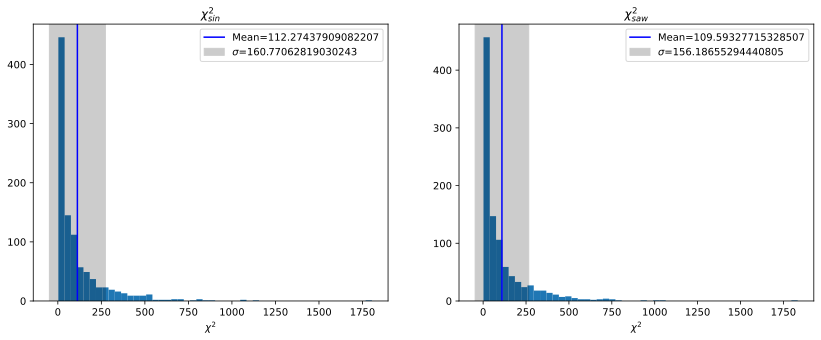

In [13]:
fig=plt.figure(figsize=(14,5))
ax0=fig.add_subplot(121)
ax1=fig.add_subplot(122)

ax0.hist(chi2_vector_sin, bins=50)
ax1.hist(chi2_vector_saw, bins=50)

ax0.set_xlabel(r'$\chi^2$')
ax0.set_title(r'$\chi^2_{sin}$')

ax1.set_xlabel(r'$\chi^2$')
ax1.set_title(r'$\chi^2_{saw}$')

mean_chi2_sin=np.mean(chi2_vector_sin)
mean_chi2_saw=np.mean(chi2_vector_saw)

ax0.axvline(mean_chi2_sin,c='b', label='Mean='+str(mean_chi2_sin))
ax1.axvline(mean_chi2_saw,c='b', label='Mean='+str(mean_chi2_saw))

std_chi2_sin=np.std(chi2_vector_sin)
std_chi2_saw=np.std(chi2_vector_saw)

ax0.axvspan(mean_chi2_sin-std_chi2_sin,mean_chi2_sin+std_chi2_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_chi2_sin))
ax1.axvspan(mean_chi2_saw-std_chi2_saw,mean_chi2_saw+std_chi2_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_chi2_saw))

ax0.legend(loc='upper right')
ax1.legend(loc='upper right');

Mean: 2.681101937536986
Standard Deviation: 23.494082694001712
Skewness: -0.32532563639792156
Kurtosis: 17.22976963423237

The number of samples in which the sawtooth model works better than the sinusoid is 587
The number of samples in which the sinusoid model works better than the sawtooth is 413
The number of samples in which the sawtooth model works as effectively as the sinusoid is 0



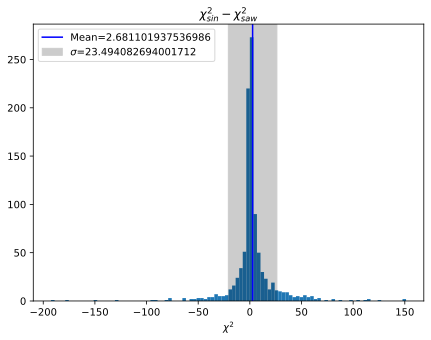

In [14]:
fig=plt.figure(figsize=(7,5))

delta_chi=chi2_vector_sin-chi2_vector_saw
plt.hist(delta_chi, bins=100);
plt.xlabel(r'$\chi^2$')
plt.title(r'$\chi^2_{sin}-\chi^2_{saw}$')

chi_distribution=delta_chi
chi_mean=np.mean(chi_distribution)
chi_std=np.std(chi_distribution)
chi_skew=scipy.stats.skew(chi_distribution)
chi_kurt=scipy.stats.kurtosis(chi_distribution)

plt.axvline(chi_mean,c='b', label='Mean='+str(chi_mean))
plt.axvspan(chi_mean-chi_std,chi_mean+chi_std,0,500, alpha=0.2, color='k', label=r'$\sigma$='+str(chi_std))

plt.legend(loc='upper left')

print("Mean:", chi_mean)
print("Standard Deviation:",chi_std)
print("Skewness:",chi_skew)
print("Kurtosis:",chi_kurt)

print()

print("The number of samples in which the sawtooth model works better than the sinusoid is", len(delta_chi[delta_chi>0]))
print("The number of samples in which the sinusoid model works better than the sawtooth is", len(delta_chi[delta_chi<0]))
print("The number of samples in which the sawtooth model works as effectively as the sinusoid is", len(delta_chi[delta_chi==0]))

print()

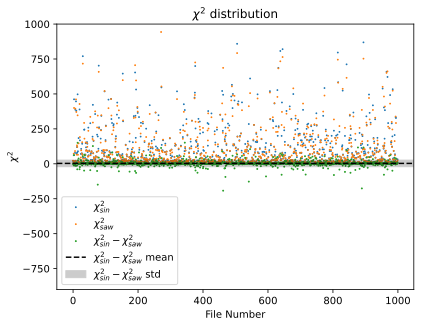

In [15]:
Nfile=np.linspace(0,999,1000)
plt.scatter(Nfile,chi2_vector_sin, s=0.8, label=r'$\chi^2_{sin}$')
plt.scatter(Nfile,chi2_vector_saw, s=0.8, label=r'$\chi^2_{saw}$')
plt.scatter(Nfile,delta_chi, s=1, label=r'$\chi^2_{sin}-\chi^2_{saw}$')
plt.axhline(chi_mean, c='k',ls='--' ,label=r'$\chi^2_{sin}-\chi^2_{saw}$ mean')
plt.axhspan(chi_mean-chi_std,chi_mean+chi_std,0,500, alpha=0.2, color='k', label=r'$\chi^2_{sin}-\chi^2_{saw}$ std')

plt.ylim(-900,1000)
plt.ylabel(r'$\chi^2$')
plt.xlabel("File Number")
plt.title(r'$\chi^2$ distribution')
plt.legend(loc='best');

## Fit Parameters

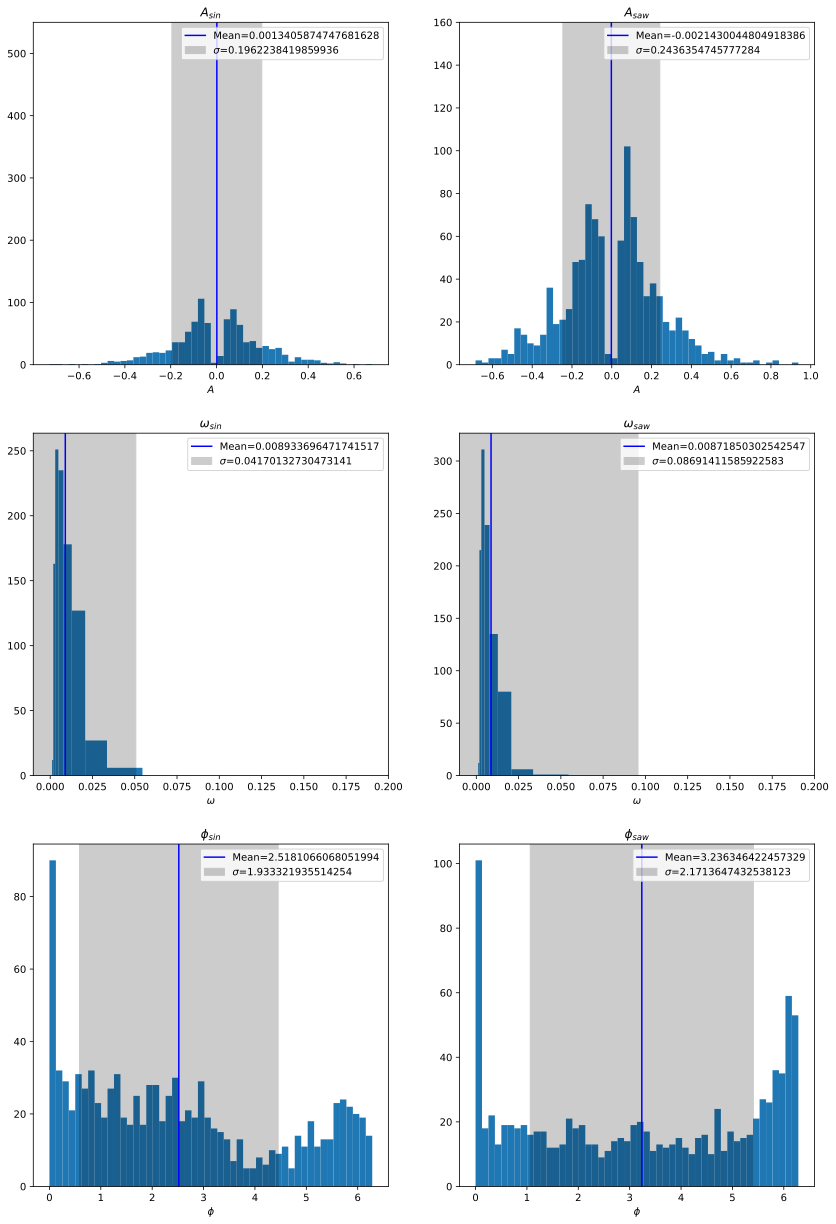

In [20]:
fig=plt.figure(figsize=(14,21))
ax0=fig.add_subplot(321)
ax1=fig.add_subplot(322)

ax0.hist(A_sin, bins=50)
ax1.hist(A_saw, bins=50)

ax0.set_xlabel(r'$A$')
ax0.set_title(r'$A_{sin}$')

ax1.set_xlabel(r'$A$')
ax1.set_title(r'$A_{saw}$')

mean_A_sin=np.mean(A_sin)
mean_A_saw=np.mean(A_saw)

ax0.axvline(mean_A_sin,c='b', label='Mean='+str(mean_A_sin))
ax1.axvline(mean_A_saw,c='b', label='Mean='+str(mean_A_saw))

std_A_sin=np.std(A_sin)
std_A_saw=np.std(A_saw)

ax0.axvspan(mean_A_sin-std_A_sin,mean_A_sin+std_A_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_A_sin))
ax1.axvspan(mean_A_saw-std_A_saw,mean_A_saw+std_A_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_A_saw))

ax0.set_ylim(0,550)
ax1.set_ylim(0,160)


ax0.legend(loc='best')
ax1.legend(loc='best');


ax0=fig.add_subplot(323)
ax1=fig.add_subplot(324)

bins = np.logspace(-4,0,20)

ax0.hist(omega_sin, bins=bins)
ax1.hist(omega_saw, bins=bins)

ax0.set_xlim(-0.01,0.2)
ax1.set_xlim(-0.01,0.2)


ax0.set_xlabel(r'$\omega$')
ax0.set_title(r'$\omega_{sin}$')

ax1.set_xlabel(r'$\omega$')
ax1.set_title(r'$\omega_{saw}$')

mean_omega_sin=np.mean(omega_sin)
mean_omega_saw=np.mean(omega_saw)

ax0.axvline(mean_omega_sin,c='b', label='Mean='+str(mean_omega_sin))
ax1.axvline(mean_omega_saw,c='b', label='Mean='+str(mean_omega_saw))

std_omega_sin=np.std(omega_sin)
std_omega_saw=np.std(omega_saw)

ax0.axvspan(mean_omega_sin-std_omega_sin,mean_omega_sin+std_omega_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_omega_sin))
ax1.axvspan(mean_omega_saw-std_omega_saw,mean_omega_saw+std_omega_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_omega_saw))

ax0.legend(loc='best')
ax1.legend(loc='best');


ax0=fig.add_subplot(325)
ax1=fig.add_subplot(326)

ax0.hist(phi_sin, bins=50)
ax1.hist(phi_saw, bins=50)

ax0.set_xlabel(r'$\phi$')
ax0.set_title(r'$\phi_{sin}$')

ax1.set_xlabel(r'$\phi$')
ax1.set_title(r'$\phi_{saw}$')

mean_phi_sin=np.mean(phi_sin)
mean_phi_saw=np.mean(phi_saw)

ax0.axvline(mean_phi_sin,c='b', label='Mean='+str(mean_phi_sin))
ax1.axvline(mean_phi_saw,c='b', label='Mean='+str(mean_phi_saw))

std_phi_sin=np.std(phi_sin)
std_phi_saw=np.std(phi_saw)

ax0.axvspan(mean_phi_sin-std_phi_sin,mean_phi_sin+std_phi_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_phi_sin))
ax1.axvspan(mean_phi_saw-std_phi_saw,mean_phi_saw+std_phi_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_phi_saw))

ax0.legend(loc='best')
ax1.legend(loc='best');

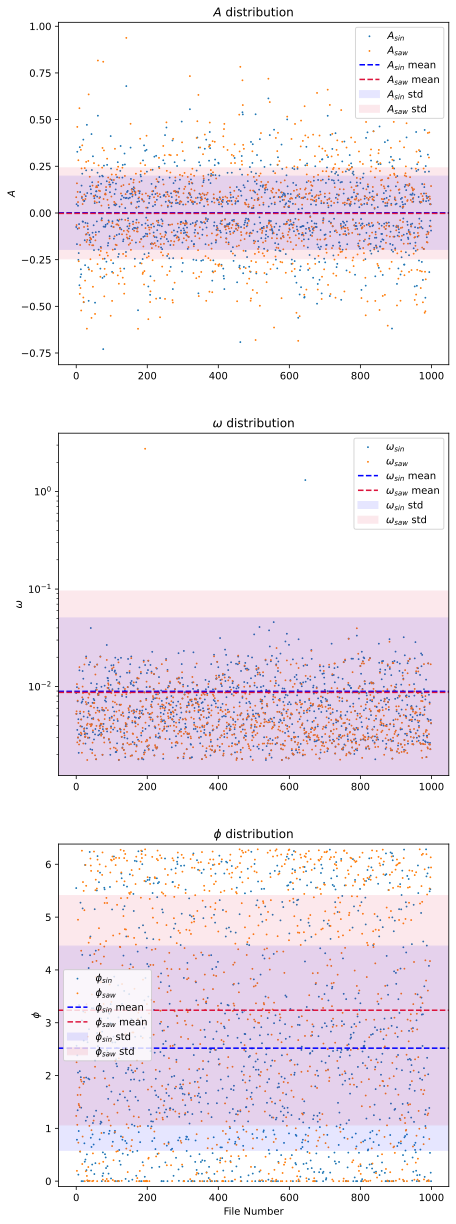

In [27]:
Nfile=np.linspace(0,999,1000)

fig=plt.figure(figsize=(7,21))
ax0=fig.add_subplot(311)
ax1=fig.add_subplot(312)
ax2=fig.add_subplot(313)

ax0.scatter(Nfile,A_sin, s=0.8, label=r'$A_{sin}$')
ax0.scatter(Nfile,A_saw, s=0.8, label=r'$A_{saw}$')

ax0.axhline(mean_A_sin, c='b',ls='--', label=r'$A_{sin}$ mean')
ax0.axhline(mean_A_saw, c='crimson',ls='--', label=r'$A_{saw}$ mean')
ax0.axhspan(mean_A_sin-std_A_sin,mean_A_sin+std_A_sin,0,500, alpha=0.1, color='b', label=r'$A_{sin}$ std')
ax0.axhspan(mean_A_saw-std_A_saw,mean_A_saw+std_A_saw,0,500, alpha=0.1, color='crimson', label=r'$A_{saw}$ std')

ax0.set_ylabel(r'$A$')
ax0.set_title(r'$A$ distribution')
ax0.legend(loc='best')

ax1.scatter(Nfile,omega_sin, s=0.8, label=r'$\omega_{sin}$')
ax1.scatter(Nfile,omega_saw, s=0.8, label=r'$\omega_{saw}$')

ax1.axhline(mean_omega_sin, c='b',ls='--', label=r'$\omega_{sin}$ mean')
ax1.axhline(mean_omega_saw, c='crimson',ls='--', label=r'$\omega_{saw}$ mean')
ax1.axhspan(mean_omega_sin-std_omega_sin,mean_omega_sin+std_omega_sin,0,500, alpha=0.1, color='b', label=r'$\omega_{sin}$ std')
ax1.axhspan(mean_omega_saw-std_omega_saw,mean_omega_saw+std_omega_saw,0,500, alpha=0.1, color='crimson', label=r'$\omega_{saw}$ std')

#ax1.set_ylim(-0.01,0.2)
ax1.set_yscale('log')
ax1.set_ylabel(r'$\omega$')
ax1.set_title(r'$\omega$ distribution')
ax1.legend(loc='best');

ax2.scatter(Nfile,phi_sin, s=0.8, label=r'$\phi_{sin}$')
ax2.scatter(Nfile,phi_saw, s=0.8, label=r'$\phi_{saw}$')

ax2.axhline(mean_phi_sin, c='b',ls='--', label=r'$\phi_{sin}$ mean')
ax2.axhline(mean_phi_saw, c='crimson',ls='--', label=r'$\phi_{saw}$ mean')
ax2.axhspan(mean_phi_sin-std_phi_sin,mean_phi_sin+std_phi_sin,0,500, alpha=0.1, color='b', label=r'$\phi_{sin}$ std')
ax2.axhspan(mean_phi_saw-std_phi_saw,mean_phi_saw+std_phi_saw,0,500, alpha=0.1, color='crimson', label=r'$\phi_{saw}$ std')

ax2.set_ylim(-0.1,2*np.pi+0.1)
ax2.set_ylabel(r'$\phi$')
ax2.set_title(r'$\phi$ distribution')
ax2.legend(loc='best');

ax2.set_xlabel("File Number");

There's clearly a big outlier in $\phi_{saw}$ that needs to be addressed

### Bestfit

In [28]:
file_min_sin=np.argmin(chi2_vector_sin)
min_sin_sin=chi2_vector_sin[file_min_sin]
min_sin_saw=chi2_vector_saw[file_min_sin]

print("The minimum value for the sin models is found in the file "+str(file_min_sin))
print("The correspondent chi squared for the sinusoidal model is",min_sin_sin,"while the correspondent chi squared for the sawtooth model is",min_sin_saw)

print()

file_min_saw=np.argmin(chi2_vector_saw)
min_saw_sin=chi2_vector_sin[file_min_saw]
min_saw_saw=chi2_vector_saw[file_min_saw]

print("The minimum value for the sin models is found in the file "+str(file_min_saw))
print("The correspondent chi squared for the sinusoidal model is",min_saw_sin,"while the correspondent chi squared for the sawtooth model is",min_saw_saw)

The minimum value for the sin models is found in the file 659
The correspondent chi squared for the sinusoidal model is 3.0579959948416855 while the correspondent chi squared for the sawtooth model is 2.8868312226554655

The minimum value for the sin models is found in the file 5
The correspondent chi squared for the sinusoidal model is 3.283249803931694 while the correspondent chi squared for the sawtooth model is 2.060169463235973


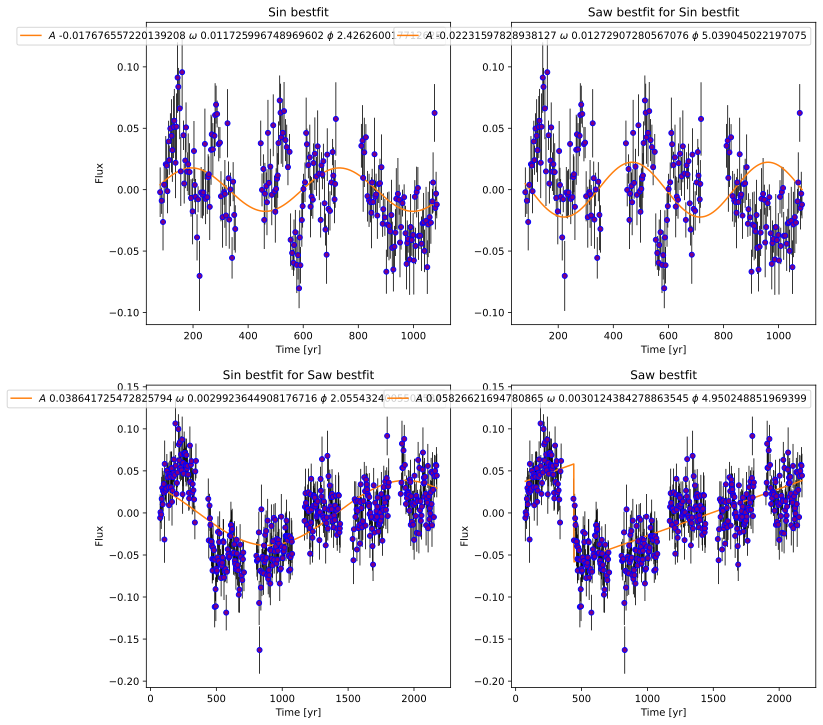

In [31]:
fig=plt.figure(figsize=(12,12))
ax0=fig.add_subplot(221)
ax1=fig.add_subplot(222)
ax2=fig.add_subplot(223)
ax3=fig.add_subplot(224)

filename_sin=name(file_min_sin)
data_sin=read(filename_sin)
ax0.errorbar(data_sin['time'],data_sin['flux'],yerr=data_sin['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_sin['time']),np.max(data_sin['time']),1000)

ax0.plot(t,sin(t,A_sin[file_min_sin],omega_sin[file_min_sin],phi_sin[file_min_sin]), label=r'$A$ '+str(A_sin[file_min_sin])+r' $\omega$ '+str(omega_sin[file_min_sin])+r' $\phi$ '+str(phi_sin[file_min_sin]))
ax0.set_xlabel('Time [yr]')
ax0.set_ylabel('Flux')
ax0.set_title('Sin bestfit')

ax0.legend(loc='best')

data_saw=read(filename_sin)
ax1.errorbar(data_saw['time'],data_saw['flux'],yerr=data_saw['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_saw['time']),np.max(data_saw['time']),1000)

ax1.plot(t,sin(t,A_saw[file_min_sin],omega_saw[file_min_sin],phi_saw[file_min_sin]), label=r'$A$ '+str(A_saw[file_min_sin])+r' $\omega$ '+str(omega_saw[file_min_sin])+r' $\phi$ '+str(phi_saw[file_min_sin]))
ax1.set_xlabel('Time [yr]')
ax1.set_title('Saw bestfit for Sin bestfit')

ax1.legend(loc='best')
         
filename_saw=name(file_min_saw)
data_sin=read(filename_saw)
ax2.errorbar(data_sin['time'],data_sin['flux'],yerr=data_sin['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_sin['time']),np.max(data_sin['time']),1000)

ax2.plot(t,sin(t,A_sin[file_min_saw],omega_sin[file_min_saw],phi_sin[file_min_saw]), label=r'$A$ '+str(A_sin[file_min_saw])+r' $\omega$ '+str(omega_sin[file_min_saw])+r' $\phi$ '+str(phi_sin[file_min_saw]))
ax2.set_xlabel('Time [yr]')
ax2.set_ylabel('Flux')
ax2.set_title('Sin bestfit for Saw bestfit')

ax2.legend(loc='best')

data_saw=read(filename_saw)
ax3.errorbar(data_saw['time'],data_saw['flux'],yerr=data_saw['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_saw['time']),np.max(data_saw['time']),1000)

ax3.plot(t,saw(t,A_saw[file_min_saw],omega_saw[file_min_saw],phi_saw[file_min_saw]), label=r'$A$ '+str(A_saw[file_min_saw])+r' $\omega$ '+str(omega_saw[file_min_saw])+r' $\phi$ '+str(phi_saw[file_min_saw]))
ax3.set_xlabel('Time [yr]')
ax3.set_ylabel('Flux')
ax3.set_title('Saw bestfit')

ax3.legend(loc='best')

In [32]:
m_vector_sin[0].migrad()

IndexError: index 0 is out of bounds for axis 0 with size 0

Fit visualization
-

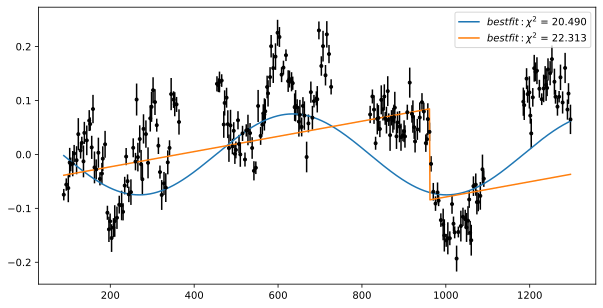

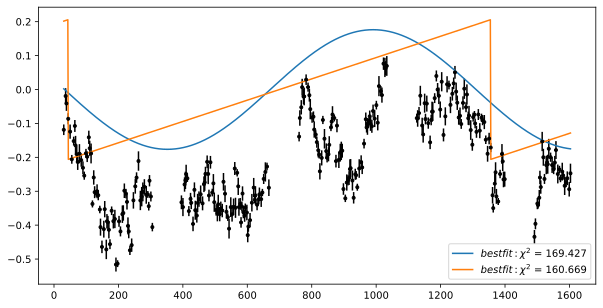

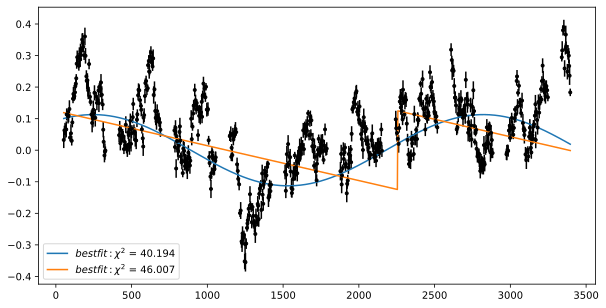

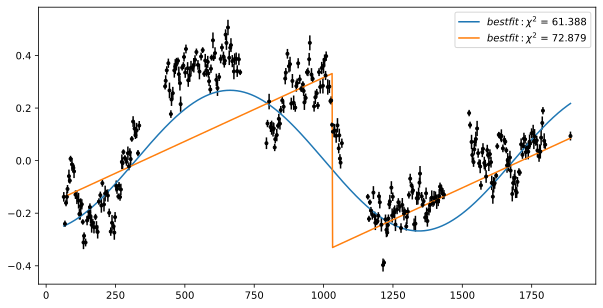

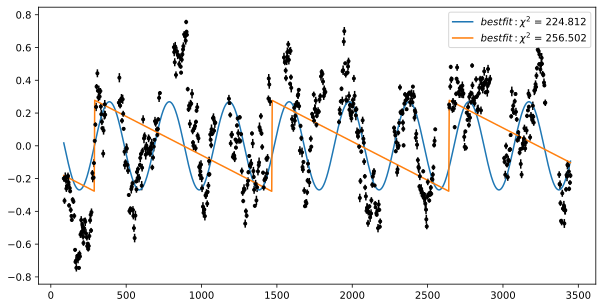

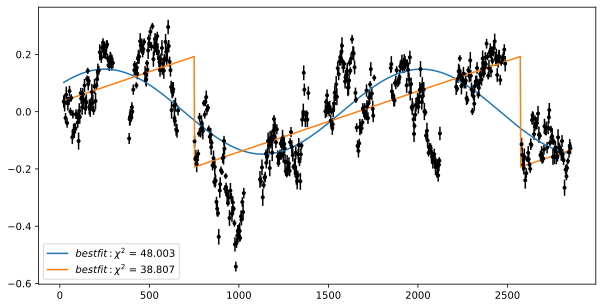

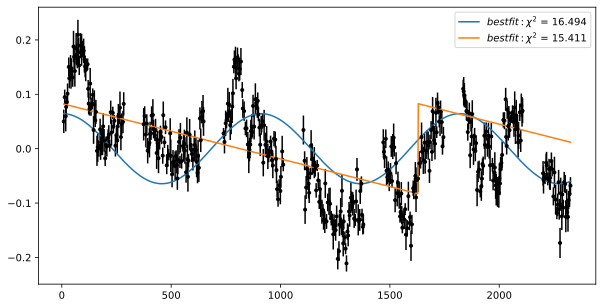

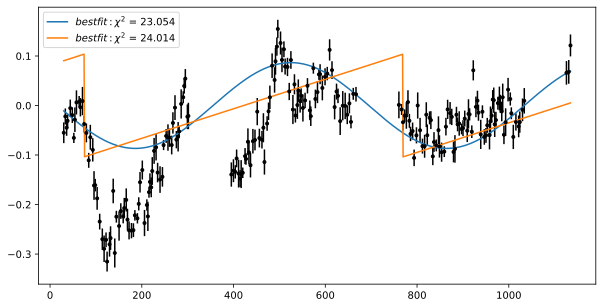

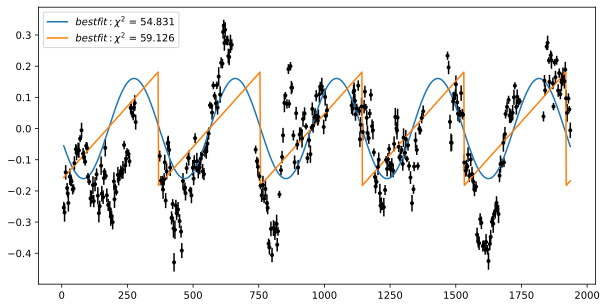

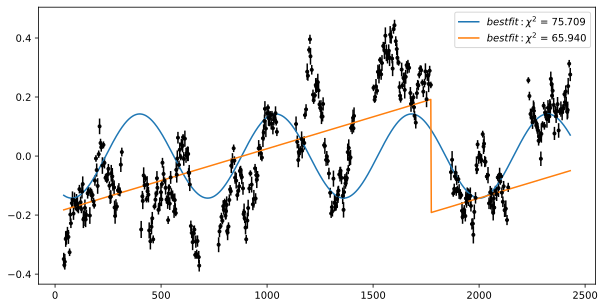

In [35]:
for imodel in range(1000)[::100]:
    fig, ax = plt.subplots(figsize=(10,5))
    file = '../../lc_%04d.txt' % imodel
        
    data = pd.read_csv(file, sep="\s+", header=None, skiprows=2)
    data.columns = ['time','flux','flux_err']
    
    plt.errorbar(data['time'],data['flux'],data['flux_err'],marker='.',c='k',linestyle='')
    
    x = np.linspace(min(data['time']),max(data['time']),1000)
    
    plt.plot(x,sin(x,A_sin[imodel],omega_sin[imodel],phi_sin[imodel]),label=r'$best fit: \chi^2 $ = %.3f' % chi2_vector_sin[imodel])
    plt.plot(x,saw(x,A_saw[imodel],omega_saw[imodel],phi_saw[imodel]),label=r'$best fit: \chi^2 $ = %.3f' % chi2_vector_saw[imodel])
    plt.legend()
    plt.plot()